# This notebook walks through an example iEFC simulation. Here, we use the control_models.py to setup an simulated vortex coronagraph and perform iEFC to create a dark hole. 

In [1]:

import numpy as np
import scipy
from scipy.optimize import minimize
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import control_models as cm 
from lina import utils, wfe, dm, iefc


/opt/conda/envs/km311esc/lib/python3.11/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import pylablib. NKT laser functionality not available.
Could not import pylablib. NKT laser functionality not available.


## Create the coronagraph model and add wavefront error. 

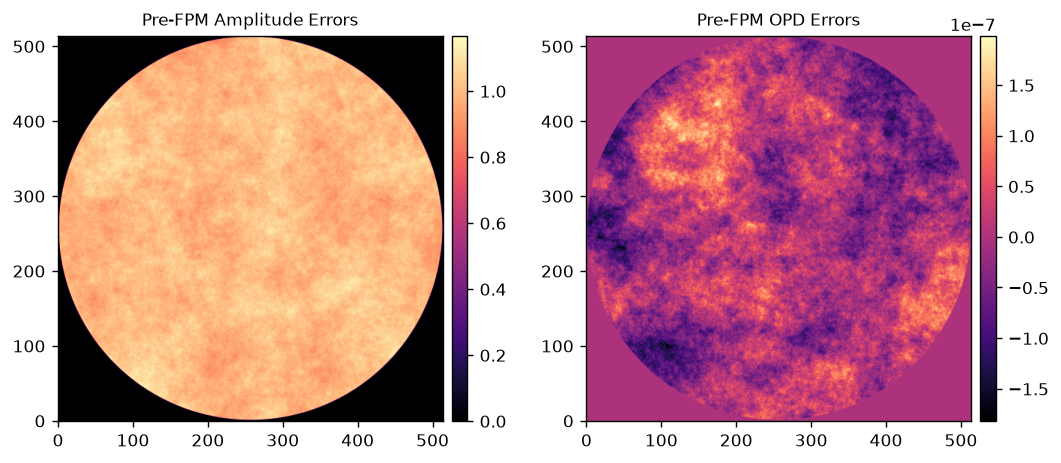

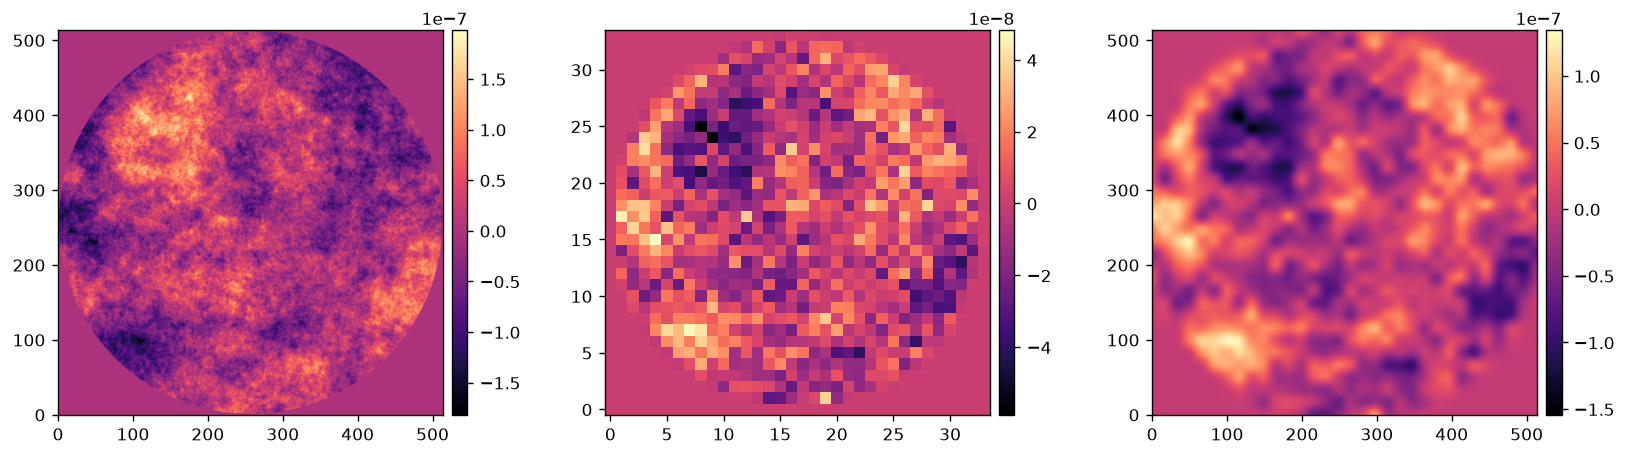

In [2]:
model_params = {
    'wavelength_c':630e-9,
    'npix':512, 
    'N_vortex_lres':2048,
    'vortex_hres_sampling':0.025, 
    'vortex_win_diam':30,
    'vortex_dot_mask_diam_lamDc':0.65,
    'ncamsci':256,
    'camsci_pxscl_lamDc':0.2, 
    'Nact':34,
    'dm_beam_diam':9.3e-3,
    'lyot_pupil_diam':5.0e-3,
    'lyot_stop_diam':4.5e-3,
    'act_spacing':300e-6,
}

C = cm.MODEL(
    **model_params,
)

prefpm_slope = 2.5
prefpm_opd_rms = 50*u.nm
prefpm_amp_rms = 0.05
prefpm_wfe_amp, prefpm_wfe_opd = wfe.generate_wfe(
    npix=C.npix, 
    oversample=C.def_oversample,
    wavelength=C.wavelength_c,
    opd_index=prefpm_slope, amp_index=prefpm_slope,
    opd_rms=prefpm_opd_rms, 
    amp_rms=prefpm_amp_rms,
    remove_amp_modes=12,
    remove_opd_modes=3,
    opd_seed=12, 
    amp_seed=123,
)
utils.imshow(
    [prefpm_wfe_amp, prefpm_wfe_opd],
    titles=['Pre-FPM Amplitude Errors', 'Pre-FPM OPD Errors'],
)

bfgs_tol = 1e-4
del_acts0 = np.zeros(C.Nacts)
res = minimize(
    cm.dm_val_and_grad, 
    jac=True, 
    x0=del_acts0, 
    args=(prefpm_wfe_opd, C),
    method='L-BFGS-B',
    tol=bfgs_tol,
    # options=options,
)

flat_command = xp.zeros((C.Nact, C.Nact))
flat_command[C.dm_mask] = xp.array(res.x)

mft_command = C.Mx_dm @ flat_command @ C.My_dm
fourier_surf = C.inf_fun_fft * mft_command
flat_command_surf = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(fourier_surf,))).real
flat_command_opd = 2 * utils.pad_or_crop(flat_command_surf, C.Ndef)

utils.imshow([prefpm_wfe_opd, flat_command, flat_command_opd],)


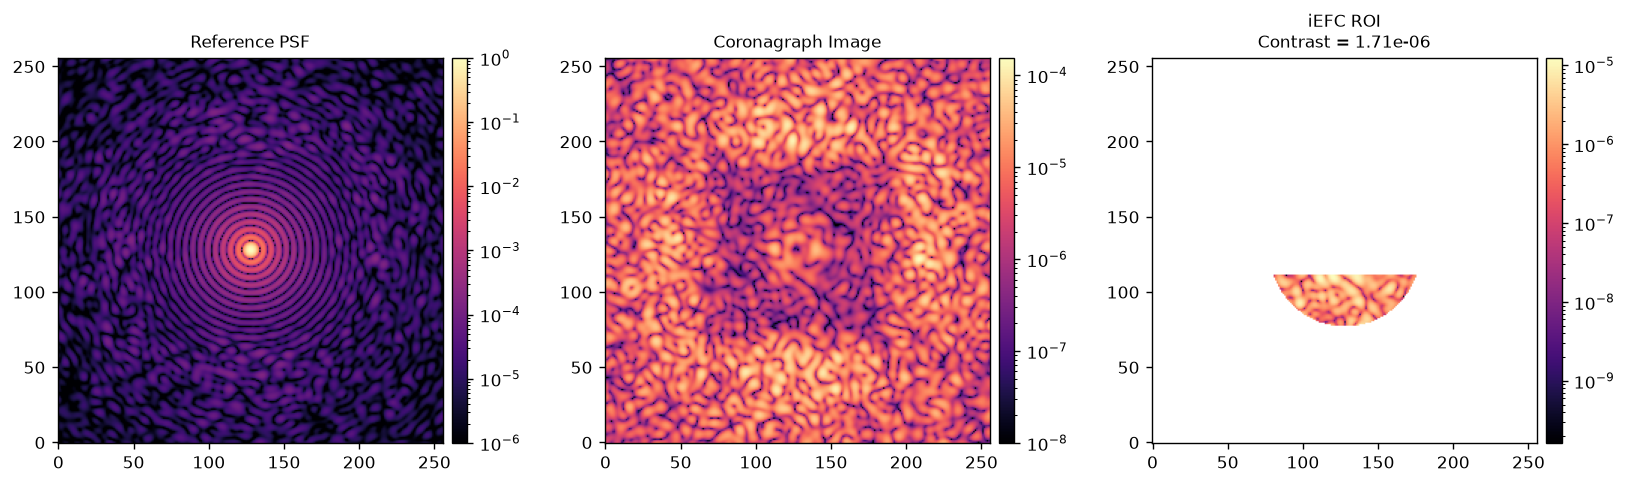

In [3]:
reload(utils)
C.PREFPM_AMP = prefpm_wfe_amp
C.PREFPM_OPD = prefpm_wfe_opd
C.dm_commands[0] = flat_command

C.Imax_ref = 1
C.use_vortex = 0
ref_psf = C.snap()
C.Imax_ref = xp.max(ref_psf)

C.use_vortex = 1
coro_im = C.snap()

iwa, owa = (3, 10)
wfs_mask = utils.create_annular_mask(
    C.ncamsci, 
    iwa, 
    owa, 
    C.camsci_pxscl_lamDc, 
    edge=iwa, 
    rotation=90, 
    centering='odd',
    # return_np=1,
)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [ref_psf/C.Imax_ref, coro_im, coro_im * wfs_mask],
    norms=[LogNorm(1e-6), LogNorm(1e-8), LogNorm()],
    titles=['Reference PSF', 'Coronagraph Image', f'iEFC ROI\nContrast = {contrast:.2e}']
    # cmaps=['magma'],
)

## Setup the functions needed for iEFC. The iEFC algorithm takes in these functions along with the function parameters in order to compute or measure images along with applying the DM commands. These wrapper functions are defined by individual users so that the iEFC algorithm itself can be model or hardware agnositic. 

In [4]:
dm_mask = dm.create_mask(Nact=C.Nact)

def take_im_fun(C):
    coro_im = C.snap()
    return coro_im

def set_dm_fun(command, C, channel=1):
    C.dm_commands[channel] = command
    return

def get_dm_fun(C, channel=1):
    return C.dm_commands[channel]

take_im_params = {'C':C}
set_dm_params = {'C':C, 'channel':3}
get_dm_params = {'C':C, 'channel':3}

## Make the probes and calibration modes. We typically use what we call Fourier probes (which are superpositions of Fourier modes that probe a particular region in the focal plane, this is similar to more classical sinc probes used in EFC literature). The calibration modes are Hadamard modes because these have been found to work well experimentally. 

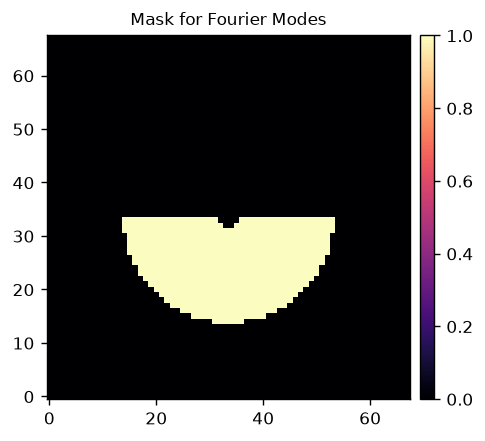

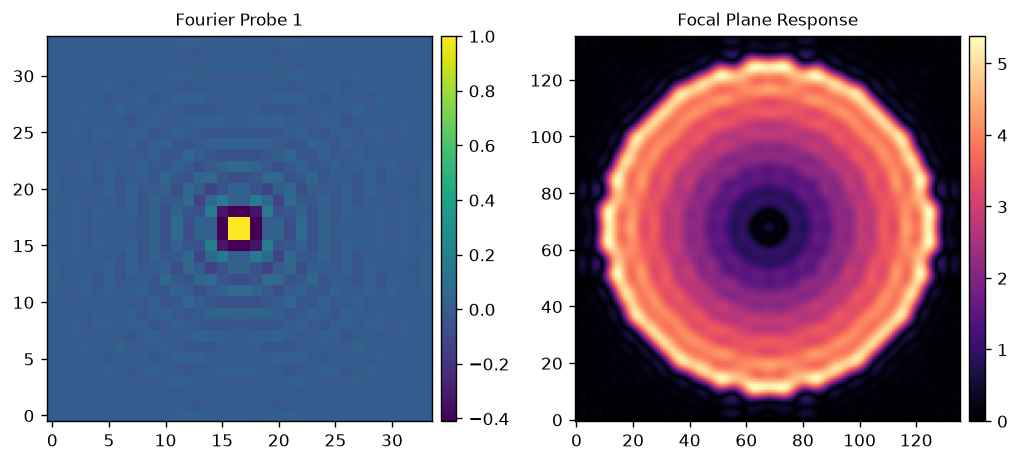

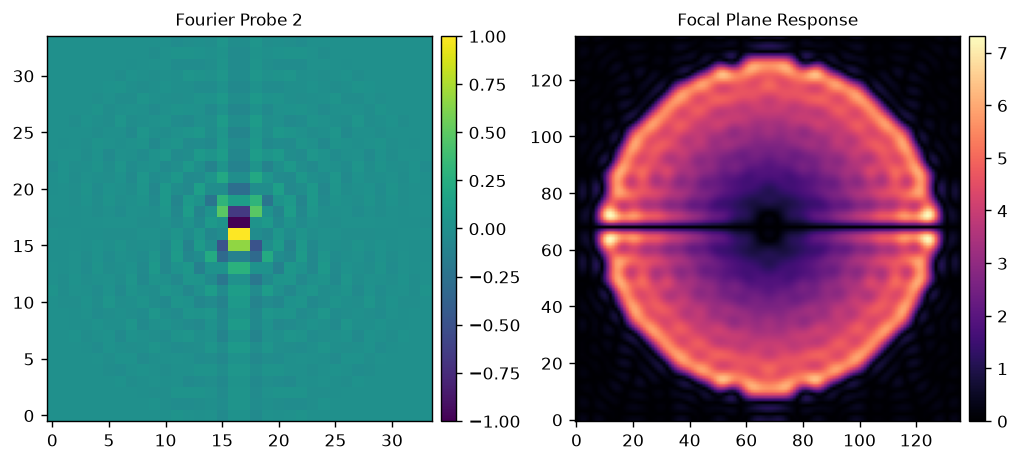

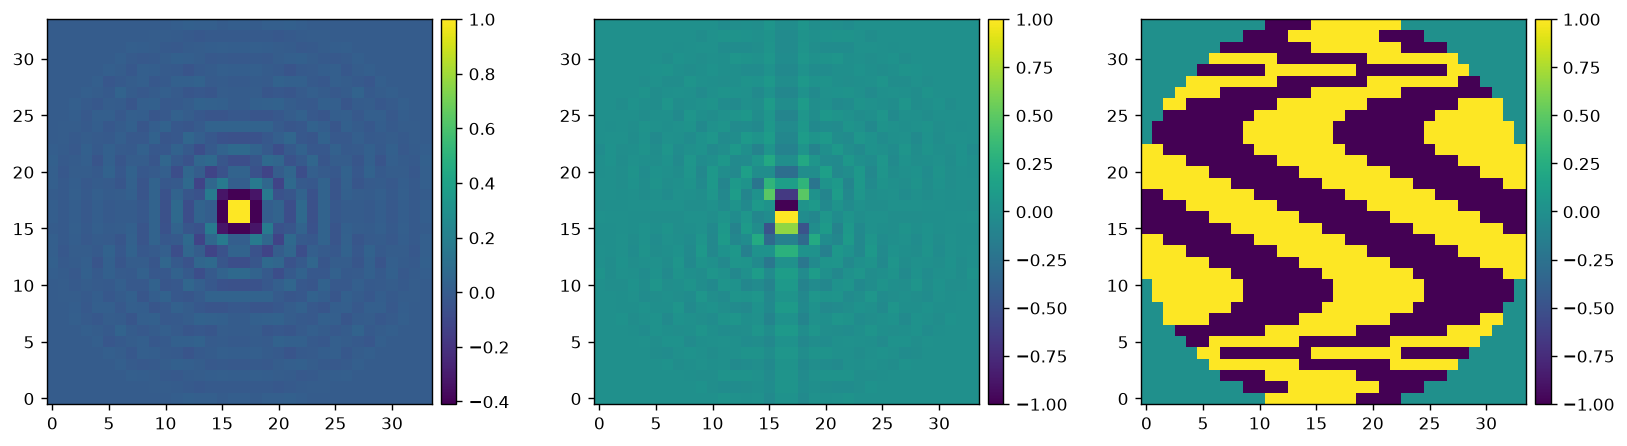

In [5]:
probe_modes = dm.create_fourier_probes(
    dm_mask, 
    C.ncamsci, 
    C.camsci_pxscl_lamDc, 
    2,
    14, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
    plot=1,
    # return_np=1, 
)

calib_modes = dm.create_hadamard_modes(
    dm_mask, 
    # return_np=1,
)

utils.imshow([probe_modes[0], probe_modes[1], calib_modes[8]], cmaps=3*['viridis'])

## Test measuring the difference images of probes.  

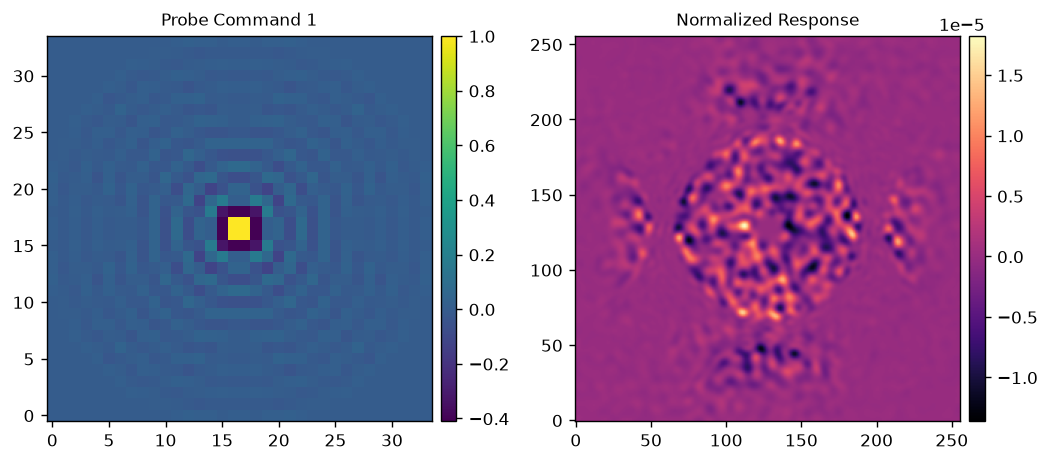

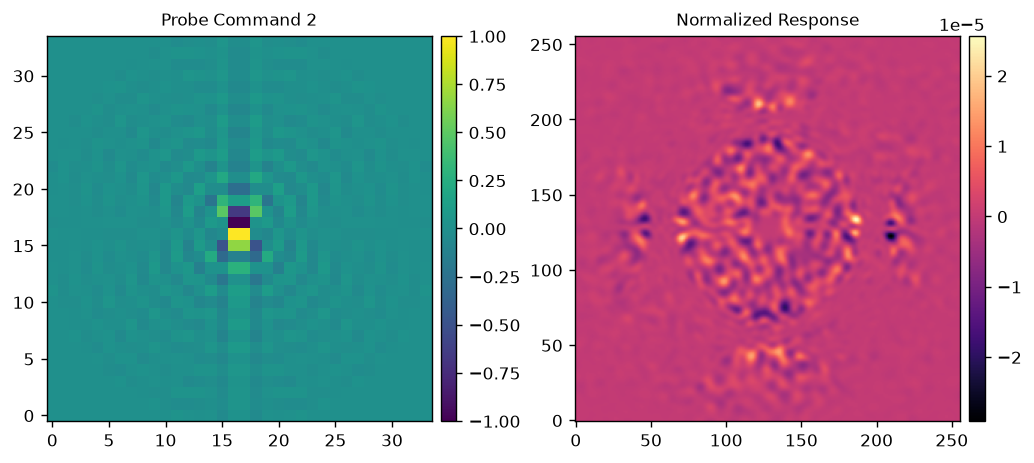

In [6]:
diff_ims = iefc.measure_probe_response(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    probe_modes,
    10e-9,
    plot=1,
)

## Perform the iEFC calibration

Calibrating iEFC...
	Calibrated mode 1024/1024 in 18.596s
Calibration complete.


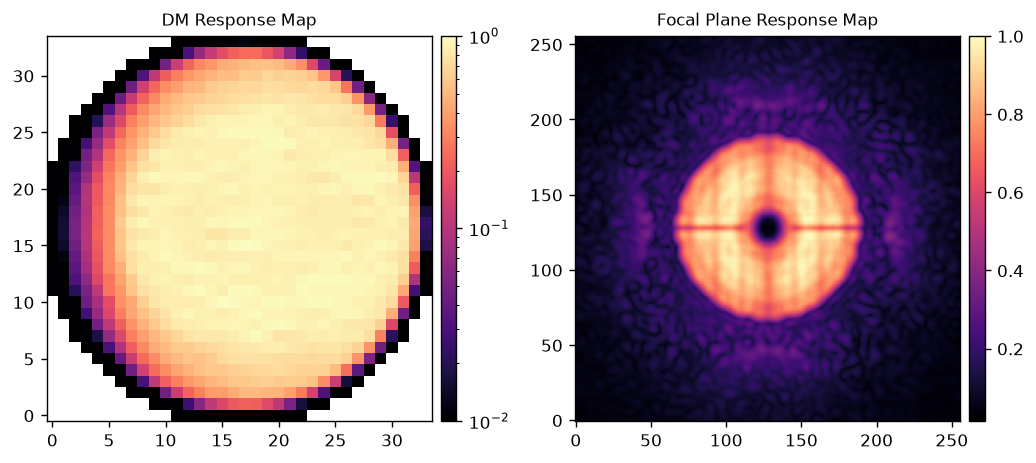

In [7]:
calib_probe_amp = 5e-9
calib_mode_amp = 2e-9

response_matrix, response_cube = iefc.calibrate(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    wfs_mask, 
    probe_modes, 
    calib_probe_amp, 
    calib_modes[:],
    calib_mode_amp, 
    scale_factors=None, 
    initial_command=None,
    normalize_diff_fun=None,
    normalize_diff_params=None,
    plot_responses=True, 
)


## Record initial coronagraphic image and initialize iEFC data dictionary.

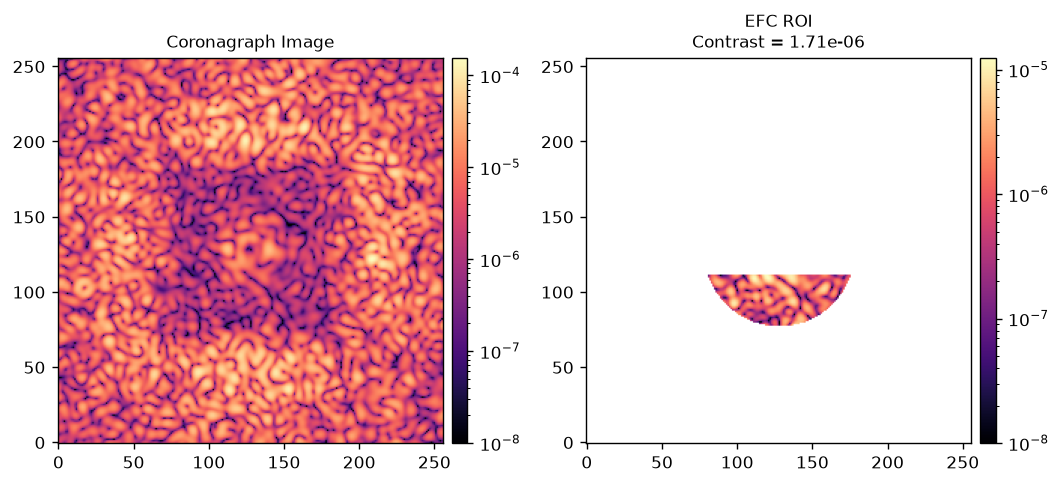

In [8]:

set_dm_fun(xp.zeros_like(dm_mask), **set_dm_params)
coro_im = take_im_fun(**take_im_params)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [coro_im, coro_im * wfs_mask],
    norms=[LogNorm(1e-8), LogNorm(1e-8)],
    titles=['Coronagraph Image', f'EFC ROI\nContrast = {contrast:.2e}'],
)

iefc_data = iefc.init_data(
    wfs_mask=wfs_mask,
    ni_im0=coro_im,
    contrast0=contrast,
)



## Run the iEFC algorithm for a set number of iterations. This cell is rerun multiple times while the beta value (the regularization parameter for the response matrix inversion) and/or the probe amplitude is updated to obtain better contrast results. 

Running iteration 7 / 8
	Measuring response of probe 1/2.
	Measuring response of probe 2/2.
Measuring dark hole state ...
	Ratio of pixels greater than zero versus total pixels: 2394 / 2394 = 1.00


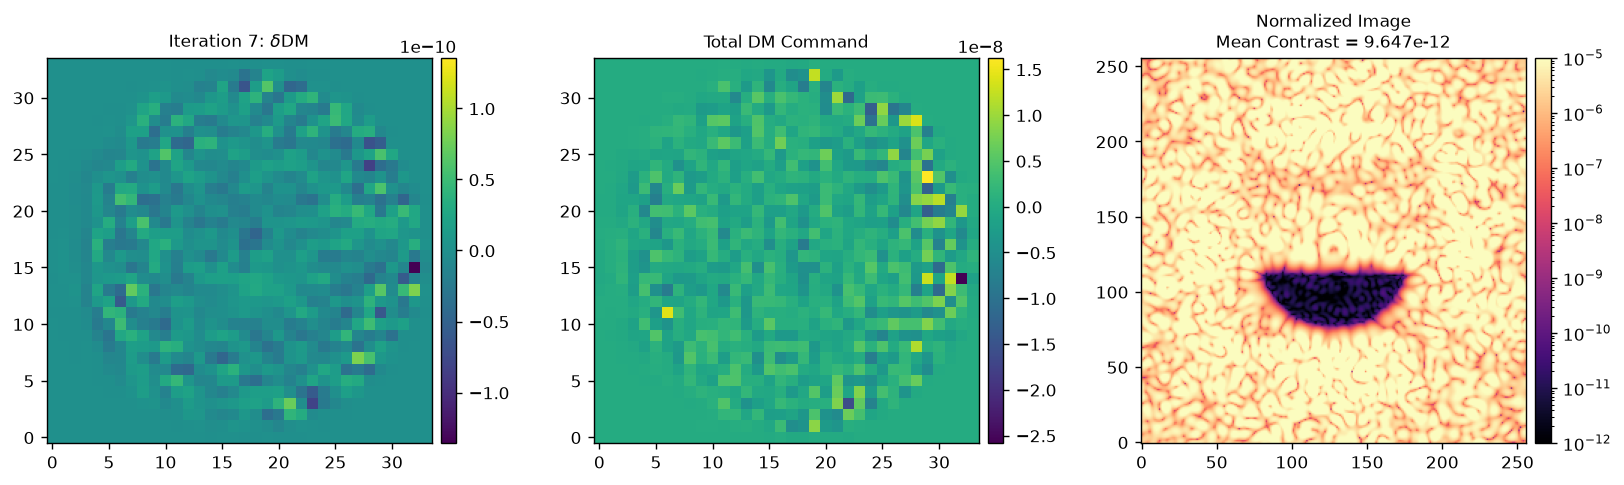

Running iteration 8 / 8
	Measuring response of probe 1/2.
	Measuring response of probe 2/2.
Measuring dark hole state ...
	Ratio of pixels greater than zero versus total pixels: 2394 / 2394 = 1.00


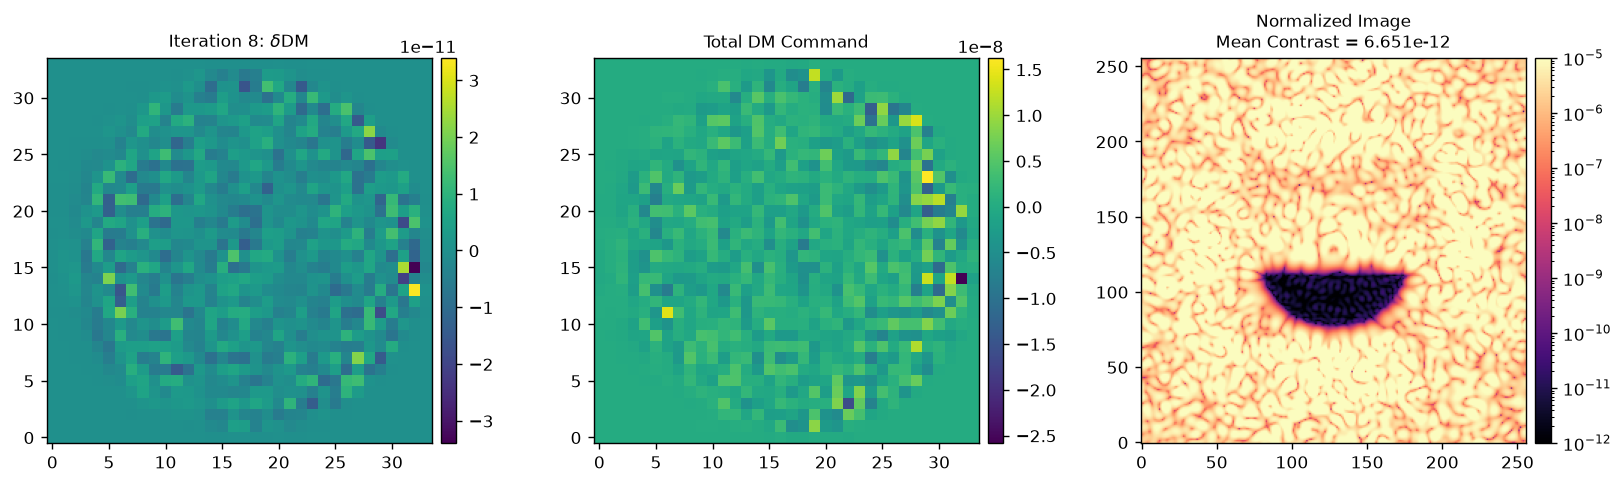

Completed 2 iterations in 0.786s.


In [12]:

probe_amp = 2.5e-9
probe_amp = 1e-9
# probe_amp = 0.5e-9
# probe_amp = 0.25e-9
# probe_amp = 0.1e-9

data = iefc.run(
    iefc_data,
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    response_matrix,
    -2.5,
    # -6.0,
    probe_modes,
    probe_amp, 
    calib_modes,
    wfs_mask,
    num_iterations=2,
    gain=1.0, 
    leakage=0.0,
    # normalize_diff_fun=None,
    # normalize_diff_params=None,
    # normalize_metric_fun=None,
    # normalize_metric_params=None,
    # plot_current=True,
    plot_all=True,
    vmin=1e-12,
)